In [1]:
## SAVING FILES EXMAPLE

# aggregated_hourly = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"
# con.execute(f"COPY services_hourly_agg TO '{aggregated_hourly}' (FORMAT PARQUET)")
# print("Done! Saved as ", aggregated_hourly)

# Prior work insights:

Lei's:
- Goal: Predict edge based on Topological features only (excluding any geographical i.e. spatial and temporal information)
- Prediction Task: Monthly edge removal prediction (supervised binary classification defined as link prediction)
- Class imbalance strategy: random undersampling
- Dynamic network
- Brute force grid search 
- Models: XGBoost best (27 models evaluated)
- Lei's trained on non simultaneous (same time), to predict on same time, simultaneous trained on network on specific time (partially) to predict the remaining part. 
- Conclusion: Showed it's possible to do edge classification (link prediction) based on (local) topological features for fast changing networks
- Future work: suggests adding to their limited feature set in various ways
- My critique/takeaway: Monthly timeline

Merel's: 
- Goal: Attempted generalizability of Lei's work to edge classification and slower changing network 
- Prediction Task: Monthly binary edge classification of 'significantly' DELAYED trajectory (supervised binary classification as edge classification)
- Class imbalance strategy: Reclassification ground truth label per trajectory (aggregated trajectory) based on entire data distribution
- Excluded weights due to leakage; compensated by adding node measurements to capture station importance instead
- Static network -> assumed due to slow changing nature 
- RandomSearchCV 
- Models: LR,RF,DT,GB,AdaBoost,XGBoost
- Conclusion: Topology features showed limited performance
- Future work: suggested to include temporal, operational and environmental data, data limitation of monthly aggregation, ensemble models
- My critique/takeaway: Monthly timeline, data (station) aggregation strategy, class imbalance strategy unsuitable, static network representation, weights were most important feature in Lei's work

Brent's:
- Goal: integrate spatial temporal features into dynamic graph based models + temporal component on daily time scale trajectory DISRUPTIONS
- Prediction Task: Daily binary edge classification of CANCELLED trajectories 
- Class imbalance strategy: tree based models scale_pos_weight, DGNN = class weighted entropy loss, SMOTE rejected due to unsuitability
- Dynamic network 
- RandomSearchCV
- Models: LR, RF, GB, XGB, DGNN (proposed)
- Conclusion: Complexity of DGNN limited performance increase, bad absolute performance, weather features not relevant, feature selection issues (LSTM permutation importance)
- Future Work: Higher resolution meteorology data, feature selection methods for sequence and graph models (to increase XAI), full scale tests with external data
- My critique/takeaways: Weather dataset quality issues, limited performance increase vs huge complexity (computation and interpretability tradeoff), XGBoost similar so back to 

Ours: 
- Goal: Reevaluate Lei's generalizability of topological features for edge classification and evaluate operational (lag and preplanned schedule information) features, environmental features for tree based models.
- Prediction task: Hourly binary edge classification of DELAYED trajectories (i.e. predicting network state; will a trajectory be delayed or not (binary), for short term delay management)
- Class imbalance strategy: classification label definition (>0min passenger experience perpective), and tree based models scale_pos_weight
- Dynamic network, due to hourly granularity
- TBD hyperparameter search space (probably randomsearch)
- Conclusion: TBD, limitations
- Future work: TBD, limitations
- Motivation for work to tackle LIMITATIONS of prior work I propose: Hourly (Merel data limitation), Stop level trajectory aggregation (Merel data limitation), Redefined classification label (Merel imbalance strategy), back to tree based models (Brent's increased complexity but limited performance increase compared to XGB in most settings), higher resolution of meteorology data (Brent's weather data limitation)


NOTES TODO (ASK):

Requiring models that capture both -> do we need to prove dependency (how, by showing correlation with spatial and temporal columns?) pearson correlation in prior work seems not quite right
Correlation with temporal column?

temporal features only lag features + (transformed) calender info enough? or require time series modeling?

Prediction task: want to add 'to what extent' (multiclass)

# Classification baseline models notebook

In [2]:
snellius = False
partition = "services_final" if snellius else "subset_week"

In [3]:
# GLOBALS
RANDOM_SEED = 88

## Imports

In [4]:
# ============================================================================
# SECTION 1: IMPORTS
# ============================================================================
# Import all necessary libraries for model training, evaluation, and visualization

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

import matplotlib.pyplot as plt

import duckdb

In [5]:
# KEY POINT: These are NOT time series sequences. Instead:
# - Each row represents ONE TRAJECTORY on ONE HOUR ON A SPECIFIC DATE
import os
from pathlib import Path

if snellius is False:
    # Change later to snellius $HOME or whatever folder you want to work in
    target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")

    # Check if it exists before moving
    if target_root.exists():
        os.chdir(target_root)
        print(f"✅ Success! Moved to: {Path.cwd()}")
    else:
        print(f"❌ Error: The folder '{target_root}' does not exist.")

✅ Success! Moved to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao


In [6]:
if snellius is True:
    # Get the home directory path object
    home_dir = Path.home() 

    # Build a path to your code
    target_root = home_dir / "NS_Thesis"

    print(target_root)

In [7]:
project_root = target_root
final_data_root = project_root / "downloads/data/filtered/final_aggregated"
final_data_filepath = final_data_root / "final_dataset.parquet"

media_folder = project_root / "media"
models_folder = project_root / "models"
results_folder = project_root / "results"

Connect duckDB database

In [8]:
## Connect to database
db_name = 'main_classifications.duckdb'

# Check before
print(f"Does file exist? {os.path.exists(db_name)}")

con = duckdb.connect(database='main_classifications.duckdb') 

# Optional: Explicitly cap RAM so DuckDB knows WHEN to start spilling
# (e.g., set to 70-80% of your actual machine RAM)
if snellius is False:
    con.execute("SET memory_limit='5GB'")   

Does file exist? True


In [10]:
# #Pandas still crashes when loading the full data, so we will load the data in duckdb and then query only a subset of the data for testing purposes. Once we are ready to train the model on the full data, we can simply change the query to select all data from the duckdb view.
# final_data_df = pd.read_parquet(final_data_filepath)
con.execute(f"CREATE OR REPLACE VIEW services_final AS SELECT * FROM read_parquet('{final_data_filepath}')") 

## Description dataset

### Column Features

FEATURE LISTS

excluded_geographical = [
	'source', 'target', 'service_date', 'arrival_hour', 'distance', 'train_type_counts'
]

features_service = [
    'source', 'target', 'service_date', 'arrival_hour', 'distance', 
    'total_services', 'train_type_counts', 'count_intercity', 
    'count_sprinter', 'count_other_trains'
]

data_leakage = [
    'total_delay_minutes', 'avg_delay_minutes', 
    'count_delayed_services', 'count_platform_changes'
]

graph_features = [
    'src_degree', 'src_weighted_degree', 'src_avg_distance', 
    'tgt_degree', 'tgt_weighted_degree', 'tgt_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index'
]

weather = [
    'temperature_2m', 'rain', 'snowfall', 'snow_depth', 
    'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm'
]

temporal_general = ['service_date', 'arrival_hour', 'is_holiday', 'month_name', 'day_name']

targets = ['target_binary', 'target_multiclass']

In [11]:
display(con.execute("DESCRIBE services_final").df())

,column_name,column_type,null,key,default,extra
0,source,VARCHAR,YES,None,None,None
1,target,VARCHAR,YES,None,None,None
2,service_date,DATE,YES,None,None,None
3,arrival_hour,BIGINT,YES,None,None,None
4,distance,INTEGER,YES,None,None,None
5,total_delay_minutes,DOUBLE,YES,None,None,None
6,avg_delay_minutes,DOUBLE,YES,None,None,None
7,count_delayed_services,BIGINT,YES,None,None,None
8,total_services,BIGINT,YES,None,None,None
9,count_platform_changes,BIGINT,YES,None,None,None


In [12]:
if snellius is True:
    display(con.execute("SUMMARIZE services_final").df())

In [13]:
# import duckdb

# # This returns a list of just the column names
# columns = duckdb.query(f"SELECT * FROM '{final_data_filepath}' LIMIT 0").columns
# print(columns)

### Class balance analysis

Classes are currently based off avg delay / services on trajectory


trajectories_no_delay: The number of rows (route/hour trajectories) where zero scheduled trains were late.

trajectories_with_delay: The number of rows where at least one scheduled train experienced a delay.

total_individual_services: The grand total of all trains scheduled across the entire dataset (the sum of the total_services column).

total_delayed_services: The actual number of late trains (the sum of the count_delayed_services column).

In [14]:
# Query to calculate trajectory-level stats
class_balance_stats = con.execute("""
    SELECT 
        COUNT(*) FILTER (WHERE target_binary = 0) as trajectories_no_delay,
        COUNT(*) FILTER (WHERE target_binary = 1) as trajectories_with_delay,
        SUM(total_services) as total_individual_services,
        SUM(count_delayed_services) as total_delayed_services
    FROM services_final
""").df()

print(class_balance_stats)

   trajectories_no_delay  trajectories_with_delay  total_individual_services  \
0               14654462                 12323433                 75303225.0   

   total_delayed_services  
0              21810838.0  


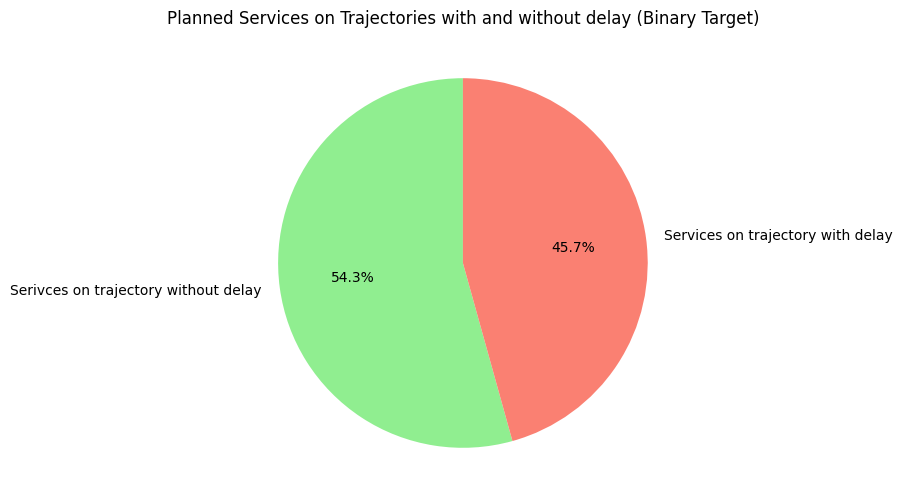

In [15]:
# Data for the pie chart
labels = ['Serivces on trajectory without delay', 'Services on trajectory with delay']
sizes = [class_balance_stats.iloc[0]['trajectories_no_delay'], class_balance_stats.iloc[0]['trajectories_with_delay']]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Planned Services on Trajectories with and without delay (Binary Target)')
plt.show()

In [16]:
# Query the existing target_multiclass column
multiclass_distribution = con.execute("""
    SELECT 
        target_multiclass, 
        COUNT(*) AS total_trajectories,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage
    FROM services_final
    GROUP BY target_multiclass
    ORDER BY target_multiclass
""").df()

print(multiclass_distribution)

   target_multiclass  total_trajectories  percentage
0                  0            14654462       54.32
1                  1            11116756       41.21
2                  2             1024471        3.80
3                  3              182206        0.68


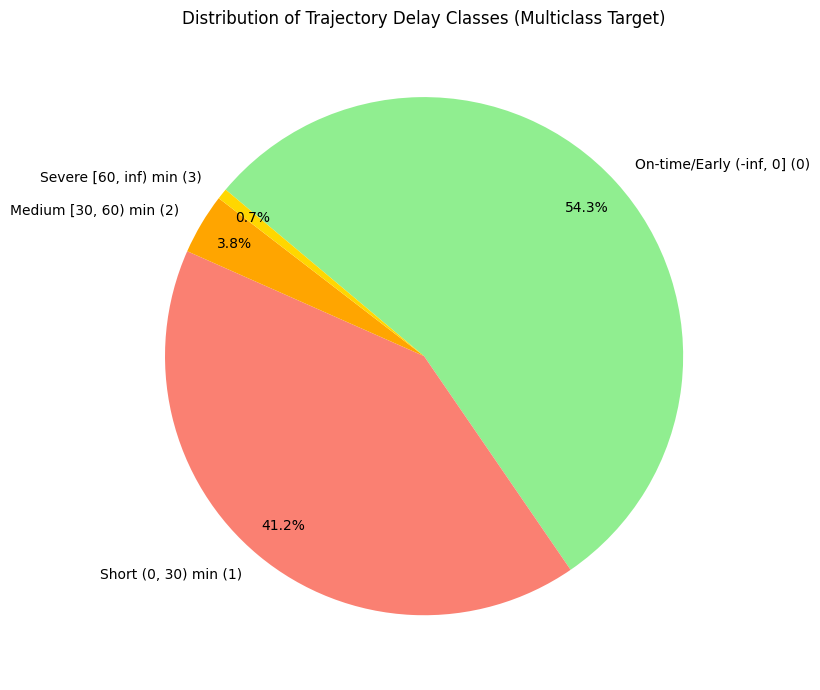

In [17]:
# 1. Force the DataFrame to follow the 0, 1, 2, 3 order
multiclass_distribution = multiclass_distribution.sort_values('target_multiclass')

# 2. Extract sizes based on that guaranteed order
sizes = multiclass_distribution['total_trajectories'].tolist()

# 3. Match labels and colors to that exact sequence
labels = [
    'On-time/Early (-inf, 0] (0)', 
    'Short (0, 30) min (1)', 
    'Medium [30, 60) min (2)', 
    'Severe [60, inf) min (3)'
]
colors = ['lightgreen', 'salmon', 'orange', 'gold']

plt.figure(figsize=(10, 7))

plt.pie(sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        pctdistance=0.85,
        counterclock=False) 

plt.title('Distribution of Trajectory Delay Classes (Multiclass Target)')
plt.tight_layout()
plt.show()

### Stations

Inclusion of ALL trains with NS label as company (Intercity, Sprinter etc.) + filtering down to NL stations resulted in 307 stations in the final services dataset

In [18]:
# Query to get the total count of unique stations
unique_stations_count = con.execute("""
    SELECT count(DISTINCT station) 
    FROM (
        SELECT source AS station FROM services_final
        UNION 
        SELECT target AS station FROM services_final
    )
""").fetchone()[0]

print(f"Total unique stations: {unique_stations_count}")

Total unique stations: 307


## Full dataset

In [19]:
if snellius is True:
    # Order by service_date, arrival_hour to ensure the data is sorted correctly
	ordered_data = con.execute("""
		CREATE OR REPLACE TABLE services_final AS
		SELECT *,
		FROM services_final
		ORDER BY service_date, arrival_hour
	""")

## SUBSET of whole dataset for testing, replace later by full

In [20]:
# Connect to your existing duckdb connection 'con'
# We add an ORDER BY to make chronological splitting easier later

if snellius is False:
    con.execute(f"""
        CREATE OR REPLACE TABLE {partition} AS 
        SELECT * FROM services_final 
        WHERE service_date >= '2019-01-01' 
          AND service_date <= '2019-01-07'
        ORDER BY service_date, arrival_hour
    """)	

    # Verify the count
    count = con.execute(f"SELECT count(*) FROM {partition}").fetchone()[0]
    print(f"Subset created with {count} rows.")


Subset created with 86302 rows.


## Initialize models

### Hyperparam search space
NOTE: We adopt best param of prior work instead for now 

But be aware of different data (distribution and class balance)

In [57]:

# Hyperparameter grids for baseline models
param_grid_lr = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['liblinear', 'saga', 'newton-cg'],
    }

param_grid_rf = {
        'n_estimators': [100, 200, 500, 1000],
        'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }

param_grid_gbdt = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],      
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)]
}

# Define scoring metrics for validation
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

In [58]:
# Assuming 'y' is defined in your scope for scale_pos_weight calculation
# ratio = sum(y == 0) / sum(y == 1) 

# 1. Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga', 'newton-cg'] 
}

# 2. Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 500, 1000],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# 3. XGBoost
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],      
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    # Ensure 'y' is defined before running this grid
    'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)] 
}

# 4. Histogram-based Gradient Boosting
# Scikit-learn's HistGradientBoostingClassifier uses 'max_iter' instead of 'n_estimators'
param_grid_hist = {
    'max_iter': [100, 200, 300],             # Equivalent to n_estimators
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7, None],            # None allows limitless depth (constrained by leaf nodes)
    'max_leaf_nodes': [15, 31, 63],          # Critical param for Hist models (31 is default)
    'l2_regularization': [0, 0.1, 1.0]       # L2 penalty
}

Training Samples: 1715 | Testing Samples: 285
Imbalance Ratio (Neg/Pos): 8.74

Starting Randomized Search and Saving Results to 'C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao\models'...

--- Tuning Logistic_Regression ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   > Best Params: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 0.001}
   > Best CV Score: 0.9159

--- Tuning Random_Forest ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\

   > Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': True}
   > Best CV Score: 0.8908

--- Tuning XGBoost ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:27:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   > Best Params: {'subsample': 0.8, 'scale_pos_weight': np.float64(8.744318181818182), 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
   > Best CV Score: 0.8838

--- Tuning HistGradientBoosting ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   > Best Params: {'max_leaf_nodes': 15, 'max_iter': 200, 'max_depth': None, 'learning_rate': 0.01, 'l2_regularization': 0}
   > Best CV Score: 0.8994

Results saved to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao\results\model_results.csv

--- Model Performance (Sorted by Balanced Accuracy) ---
               Model  Balanced Accuracy  F1 Score  AUC-ROC
 Logistic_Regression           0.839911  0.567901 0.936827
HistGradientBoosting           0.830819  0.636364 0.881129
       Random_Forest           0.806102  0.644068 0.914063
             XGBoost           0.802196  0.622951 0.907664


C:\Users\jialo\AppData\Local\Temp\ipykernel_13192\939868790.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Balanced Accuracy", y="Model", data=results_df, palette="viridis")


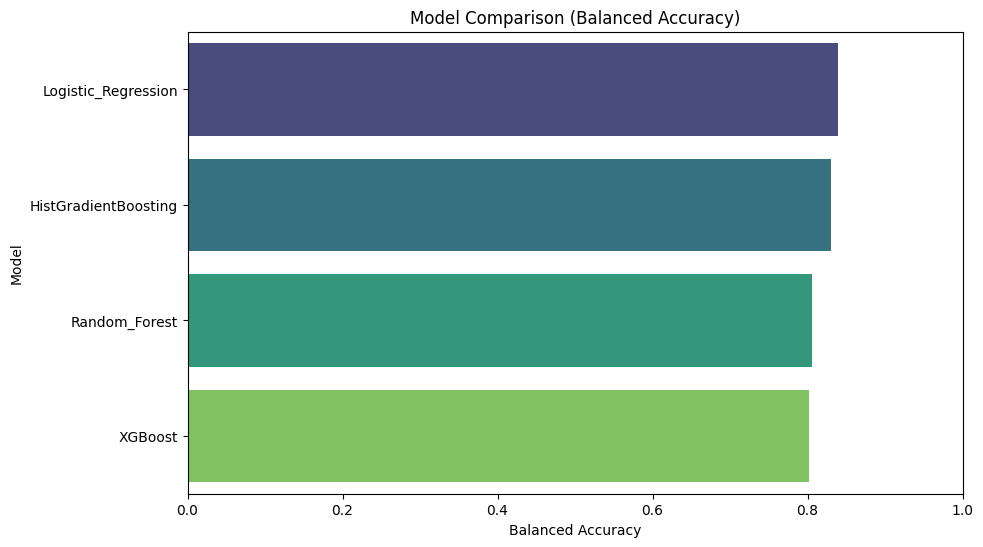


Winner: Logistic_Regression (File: Logistic_Regression_best.pkl)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib 
from tqdm import tqdm
from scipy.stats import uniform, randint, loguniform

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

# --- Preprocessing & Tuning ---
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, roc_auc_score, balanced_accuracy_score

import shap

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================

models_folder = models_folder
if not os.path.exists(models_folder):
    os.makedirs(models_folder)

# RANDOM SEED
RANDOM_SEED = 88

# ### ACTION REQUIRED: Load your dataset here ###
# df = pd.read_csv('your_dataset.csv')

# --- DEMO DATA GENERATION (DELETE THIS BLOCK) ---
from sklearn.datasets import make_classification
X_dummy, y_dummy = make_classification(n_samples=2000, n_features=10, weights=[0.9, 0.1], random_state=42)
df = pd.DataFrame(X_dummy, columns=[f'feature_{i}' for i in range(10)])
df['Target_Column'] = y_dummy
df['Year'] = np.sort(np.random.choice(range(2010, 2025), size=2000))
# -------------------------------------------------------------------------

# ### ACTION REQUIRED: Configuration ###
target_col = 'Target_Column'
time_col = 'Year'   
split_threshold = 2023  # Train on data before 2023, Test on 2023+

feature_cols = [c for c in df.columns if c not in [target_col, time_col]]

# ==========================================
# 2. TEMPORAL SPLIT & PREPROCESSING
# ==========================================

# 1. Sort by Time
df = df.sort_values(by=time_col).reset_index(drop=True)

# 2. Encode Categoricals
for col in df[feature_cols].select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 3. Create Split Mask
train_mask = df[time_col] < split_threshold
test_mask = df[time_col] >= split_threshold

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, target_col]
X_test = df.loc[test_mask, feature_cols]
y_test = df.loc[test_mask, target_col]

# 4. Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Calculate Weights (for XGBoost)
count_neg = np.sum(y_train == 0)
count_pos = np.sum(y_train == 1)
scale_pos_weight_value = count_neg / count_pos

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")
print(f"Imbalance Ratio (Neg/Pos): {scale_pos_weight_value:.2f}")

# ==========================================
# 3. HYPERPARAMETER GRIDS (Updated)
# ==========================================

tscv = TimeSeriesSplit(n_splits=5) 

param_grids = {
    "Logistic_Regression": {
        "model": LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED),
        "params": {
			'C': [0.001, 0.01, 0.1, 1, 10, 100],
			'penalty': ['l1', 'l2', 'elasticnet'],
			'solver': ['liblinear', 'saga', 'newton-cg'],
        }
    },
    "Random_Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1),
        "params": {
			'n_estimators': [100, 200, 500, 1000],
			'max_features': ['auto', 'sqrt', 'log2'],
			'max_depth': [10, 20, 30, None],
			'min_samples_split': [2, 5, 10],
			'min_samples_leaf': [1, 2, 4],
			'bootstrap': [True, False]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED, n_jobs=-1),
        "params": {
			'max_depth': [3, 5, 7],
			'learning_rate': [0.01, 0.1, 0.3],      
			'n_estimators': [100, 200, 300],
			'subsample': [0.6, 0.8, 1.0],
			'colsample_bytree': [0.6, 0.8, 1.0],
			'scale_pos_weight': [1, scale_pos_weight_value]
        }
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_SEED),
        "params": {
            'max_iter': [100, 200, 300],          # Equivalent to n_estimators
            'learning_rate': [0.01, 0.1, 0.3],
            'max_depth': [3, 5, 7, None],
            'max_leaf_nodes': [15, 32, 64],      # Critical for HistBoost
            'l2_regularization': [0, 0.1, 1.0, 10]
        }
    }
}


scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
	'balanced_accuracy': make_scorer(balanced_accuracy_score)
}

# ==========================================
# 4. TUNING LOOP & SAVING
# ==========================================

results = []
print(f"\nStarting Randomized Search and Saving Results to '{models_folder}'...")


for name, config in param_grids.items(): 
    print(f"\n--- Tuning {name} ---")
    
    # Run Search
    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=10,           
        scoring=scoring,
        refit='balanced_accuracy',  # Refitting on the best model according to balanced accuracy          
		cv=tscv, 
        verbose=1,
		n_jobs=-1, 
		random_state=RANDOM_SEED,
    )
    
    search.fit(X_train_scaled, y_train)
    best_model = search.best_estimator_
    
    # --- PRINT BEST PARAMETERS (ADDED) ---
    print(f"   > Best Params: {search.best_params_}")
    print(f"   > Best CV Score: {search.best_score_:.4f}")

    # --- SAVE MODEL ---
    model_filename = f"{name}_best.pkl"
    joblib.dump(best_model, os.path.join(models_folder, model_filename))
    
    # Predict
    y_pred = best_model.predict(X_test_scaled)
    
    # Calculate Metrics
    f1 = f1_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    try:
        y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = 0
        
    results.append({
        "Model": name,
        "Balanced Accuracy": bal_acc,
        "F1 Score": f1,
        "AUC-ROC": auc,
        "Best Params": search.best_params_,
        "Saved File": model_filename
    })

# ==========================================
# 5. RESULTS SAVING & VISUALIZATION
# ==========================================

results_df = pd.DataFrame(results).sort_values(by="Balanced Accuracy", ascending=False)

# --- SAVE RESULTS TO CSV ---
results_path = os.path.join(results_folder, 'model_results.csv')
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")

print("\n--- Model Performance (Sorted by Balanced Accuracy) ---")
# Using tabulate format or simpler string conversion for readability
print(results_df[['Model', 'Balanced Accuracy', 'F1 Score', 'AUC-ROC']].to_string(index=False))

# Plotting Balanced Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x="Balanced Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Model Comparison (Balanced Accuracy)")
plt.xlim(0, 1.0) 
plt.show()

# Show report for winner
winner = results_df.iloc[0]
print(f"\nWinner: {winner['Model']} (File: {winner['Saved File']})")